In [63]:
import numpy as np

import networkx as nx
from itertools import product, combinations

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter


from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

from qopt_best_practices.sat_mapping import SATMapper
from qiskit_qaoa.utils.circuit_graph_utils import circuit_to_graph, graph_to_operator

from qubo_qaoa.utils.swap_strategy import QUBOSwapStrategy

In [64]:
qc = QuantumCircuit(4)
p = Parameter('a')
qc.rz(p, 0)
qc.rzz(p, 0, 1)
qc.rz(p, 2)
qc.rzz(p, 2, 3)
qc.rzz(p, 0, 3)
qc.draw(fold=-1)

┌───────┐                
q_0: ┤ Rz(a) ├─■───────■──────
     └───────┘ │ZZ(a)  │      
q_1: ──────────■───────┼──────
     ┌───────┐         │      
q_2: ┤ Rz(a) ├─■───────┼──────
     └───────┘ │ZZ(a)  │ZZ(a) 
q_3: ──────────■───────■──────

In [65]:
swap_strat = QUBOSwapStrategy.from_heavy_hex(1, 1)

In [66]:
swap_strat.swap_layer(0)

[(9, 2), (8, 1), (6, 0), (7, 3), (10, 4), (11, 5)]

In [67]:
service = QiskitRuntimeService(name='eu_test_instance')
backend = service.least_busy(min_num_qubits=4, operational=True, simulator=False) 

In [68]:
backend.configuration().basis_gates

['ecr', 'id', 'rz', 'sx', 'x']

In [69]:
backend.configuration().basis_gates=['rz', 'rx', 'rzz', 'h', 'swap', 'cx']

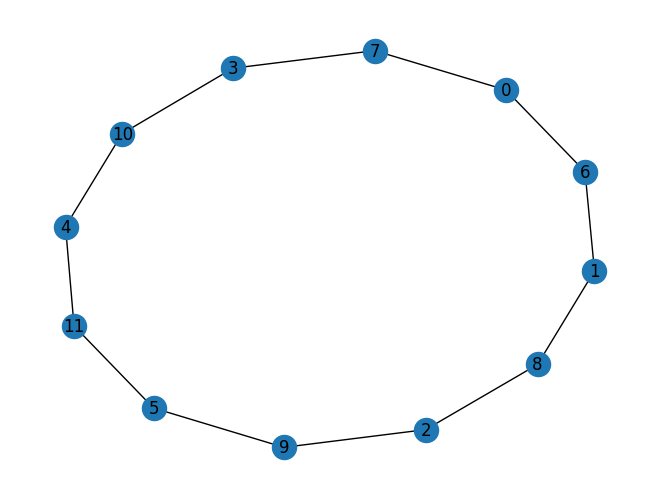

In [71]:
gg = nx.Graph()
gg.add_edges_from(swap_strat._coupling_map)
nx.draw(gg, with_labels=True)

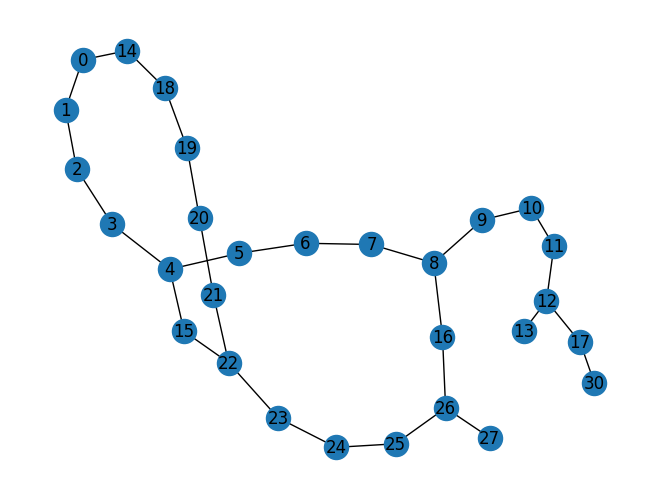

In [72]:
g = nx.Graph()
g.add_edges_from(backend.configuration().coupling_map[:30])
nx.draw(g, with_labels=True)

In [73]:
sat_map = {0: 10, 1: 3, 2: 11, 3: 5}

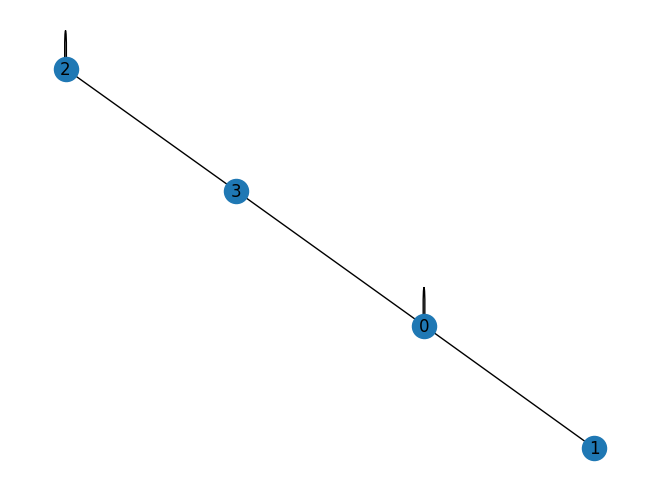

In [74]:
graph = circuit_to_graph(qc, p)
nx.draw(graph, with_labels=True)

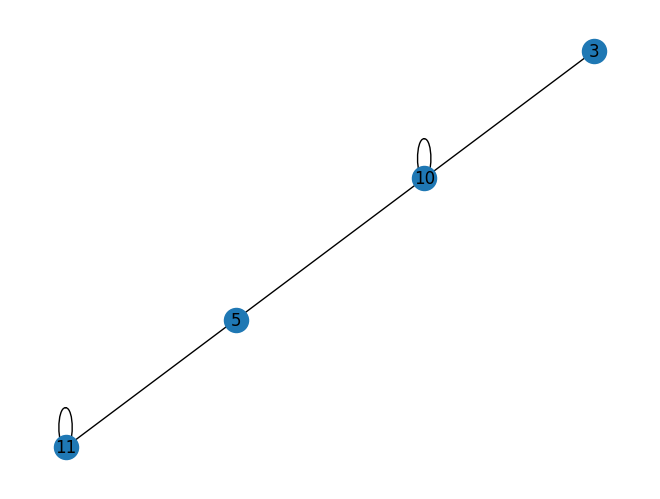

In [75]:
remapped_graph = nx.relabel_nodes(graph, sat_map)
nx.draw(remapped_graph, with_labels=True)

In [76]:
cost_op = graph_to_operator(remapped_graph, swap_strat._num_vertices)


In [77]:
coupling_map = swap_strat._coupling_map
coupling_map_edge = list(coupling_map)
physical_qubits = list(coupling_map.physical_qubits)

dual_coupling_map = nx.Graph()
for qubit in physical_qubits:
    edges = [edge for edge in coupling_map_edge if edge[0]==qubit]
    for edge1, edge2 in combinations(edges, 2):
        dual_coupling_map.add_edge(tuple(sorted(edge1)), tuple(sorted(edge2)))
edge_colouring = nx.greedy_color(dual_coupling_map, interchange=True)
edge_colouring_copy = {}
for k, v in edge_colouring.items():
    edge_colouring_copy[k] = v
    edge_colouring_copy[k[::-1]] = v


In [78]:
from qopt_best_practices.transpilation import qaoa_swap_strategy_pm
from qiskit.circuit.library import PauliEvolutionGate

n = cost_op.num_qubits
doubles_circ = QuantumCircuit(n)
doubles_circ.append(PauliEvolutionGate(cost_op[cost_op.paulis.z.sum(axis=-1) == 2], time=p), range(n))

config = {
    "num_layers": 1,
    "swap_strategy": swap_strat,
    "edge_coloring": edge_colouring_copy,
    "construct_qaoa": False,
    "basis_gates": ["rz", "cx", "swap"]
}
properties = {}
def get_permutation(pass_, dag, time, property_set, count):
    properties["virtual_permutation_layout"] = property_set["virtual_permutation_layout"]
pm = qaoa_swap_strategy_pm(config)
t_doubles_circ: QuantumCircuit = pm.run(doubles_circ, callback=get_permutation)

In [79]:
t_doubles_circ.draw(fold=-1)

q_3 -> 3 ──■──────────────────■────────────────────────────────
             │                  │             ┌───┐┌───────┐┌───┐
  q_4 -> 4 ──┼──────────────────┼────────X────┤ X ├┤ Rz(a) ├┤ X ├
             │                  │        │    └─┬─┘└───────┘└─┬─┘
  q_5 -> 5 ──┼────■─────────────┼────■───┼──X───┼─────────────┼──
           ┌─┴─┐  │  ┌───────┐┌─┴─┐  │   │  │   │             │  
q_10 -> 10 ┤ X ├──┼──┤ Rz(a) ├┤ X ├──┼───X──┼───┼─────────────┼──
           └───┘┌─┴─┐├───────┤└───┘┌─┴─┐    │   │             │  
q_11 -> 11 ─────┤ X ├┤ Rz(a) ├─────┤ X ├────X───■─────────────■──
                └───┘└───────┘     └───┘

In [80]:
singles_circ = QuantumCircuit(n)
singles_circ.append(PauliEvolutionGate(cost_op[cost_op.paulis.z.sum(axis=-1) == 1], time=t_doubles_circ.parameters[0]), range(n))

In [81]:
from qiskit import transpile

In [82]:
tsingles: QuantumCircuit = transpile(singles_circ, basis_gates=["rz"])
cost_circ: QuantumCircuit = tsingles.compose(t_doubles_circ, inplace=False)

In [83]:
cost_circ.draw(fold=-1)

q_0: ───────────────────────────────────────────────────────────────
                                                                     
 q_1: ───────────────────────────────────────────────────────────────
                                                                     
 q_2: ───────────────────────────────────────────────────────────────
                                                                     
 q_3: ───────────■──────────────────■────────────────────────────────
                 │                  │             ┌───┐┌───────┐┌───┐
 q_4: ───────────┼──────────────────┼────────X────┤ X ├┤ Rz(a) ├┤ X ├
                 │                  │        │    └─┬─┘└───────┘└─┬─┘
 q_5: ───────────┼────■─────────────┼────■───┼──X───┼─────────────┼──
                 │    │             │    │   │  │   │             │  
 q_6: ───────────┼────┼─────────────┼────┼───┼──┼───┼─────────────┼──
                 │    │             │    │   │  │   │             │  
 q_7: ───────────┼────┼─────────────┼────┼───┼──┼───┼─────────────┼──
                 │    │             │    │   │  │   │             │  
 q_8: ───────────┼────┼─────────────┼────┼───┼──┼───┼─────────────┼──
                 │    │             │    │   │  │   │             │  
 q_9: ───────────┼────┼─────────────┼────┼───┼──┼───┼─────────────┼──
      ┌───────┐┌─┴─┐  │  ┌───────┐┌─┴─┐  │   │  │   │             │  
q_10: ┤ Rz(a) ├┤ X ├──┼──┤ Rz(a) ├┤ X ├──┼───X──┼───┼─────────────┼──
      ├───────┤└───┘┌─┴─┐├───────┤└───┘┌─┴─┐    │   │             │  
q_11: ┤ Rz(a) ├─────┤ X ├┤ Rz(a) ├─────┤ X ├────X───■─────────────■──
      └───────┘     └───┘└───────┘     └───┘

In [84]:
qaoa_circ = QuantumCircuit(n, 4)
qaoa_circ.h([x for x in sat_map.values()])
qaoa_circ.compose(cost_circ, range(n), inplace=True)
qaoa_circ.barrier()
beta = Parameter('b')
qaoa_circ.rx(-2 * beta, [properties['virtual_permutation_layout'].get_physical_bits()[x] for x in sat_map.values()])
qaoa_circ.barrier()
if properties["virtual_permutation_layout"]:
    inv_sat_map = {v: k for k, v in sat_map.items()}
    for cidx, qidx in [(inv_sat_map[x], properties['virtual_permutation_layout'].get_physical_bits()[x]) for x in sat_map.values()]:
        qaoa_circ.measure(qidx, cidx)

In [86]:
test_qaoa_circ = QuantumCircuit(4)
test_qaoa_circ.h(range(4))
test_qaoa_circ.compose(qc, range(4), inplace=True)
test_qaoa_circ.barrier()
test_qaoa_circ.rx(-2*beta, range(4))
test_qaoa_circ.measure_all()
test_qaoa_circ.draw(fold=-1)

┌───┐┌───────┐                 ░ ┌────────────┐ ░ ┌─┐         
   q_0: ┤ H ├┤ Rz(a) ├─■───────■───────░─┤ Rx((-2)*b) ├─░─┤M├─────────
        ├───┤└───────┘ │ZZ(a)  │       ░ ├────────────┤ ░ └╥┘┌─┐      
   q_1: ┤ H ├──────────■───────┼───────░─┤ Rx((-2)*b) ├─░──╫─┤M├──────
        ├───┤┌───────┐         │       ░ ├────────────┤ ░  ║ └╥┘┌─┐   
   q_2: ┤ H ├┤ Rz(a) ├─■───────┼───────░─┤ Rx((-2)*b) ├─░──╫──╫─┤M├───
        ├───┤└───────┘ │ZZ(a)  │ZZ(a)  ░ ├────────────┤ ░  ║  ║ └╥┘┌─┐
   q_3: ┤ H ├──────────■───────■───────░─┤ Rx((-2)*b) ├─░──╫──╫──╫─┤M├
        └───┘                          ░ └────────────┘ ░  ║  ║  ║ └╥┘
meas: 4/═══════════════════════════════════════════════════╩══╩══╩══╩═
                                                           0  1  2  3

In [85]:
qaoa_circ.draw(fold=-1)

░                ░             
 q_0: ─────────────────────────────────────────────────────────────────────░────────────────░─────────────
                                                                           ░                ░             
 q_1: ─────────────────────────────────────────────────────────────────────░────────────────░─────────────
                                                                           ░                ░             
 q_2: ─────────────────────────────────────────────────────────────────────░────────────────░─────────────
      ┌───┐                                                                ░ ┌────────────┐ ░    ┌─┐      
 q_3: ┤ H ├───────────■──────────────────■─────────────────────────────────░─┤ Rx((-2)*b) ├─░────┤M├──────
      └───┘           │                  │             ┌───┐┌───────┐┌───┐ ░ ├────────────┤ ░ ┌─┐└╥┘      
 q_4: ────────────────┼──────────────────┼────────X────┤ X ├┤ Rz(a) ├┤ X ├─░─┤ Rx((-2)*b) ├─░─┤M├─╫───────
      ┌───┐           │                  │        │    └─┬─┘└───────┘└─┬─┘ ░ ├────────────┤ ░ └╥┘ ║ ┌─┐   
 q_5: ┤ H ├───────────┼────■─────────────┼────■───┼──X───┼─────────────┼───░─┤ Rx((-2)*b) ├─░──╫──╫─┤M├───
      └───┘           │    │             │    │   │  │   │             │   ░ └────────────┘ ░  ║  ║ └╥┘   
 q_6: ────────────────┼────┼─────────────┼────┼───┼──┼───┼─────────────┼───░────────────────░──╫──╫──╫────
                      │    │             │    │   │  │   │             │   ░                ░  ║  ║  ║    
 q_7: ────────────────┼────┼─────────────┼────┼───┼──┼───┼─────────────┼───░────────────────░──╫──╫──╫────
                      │    │             │    │   │  │   │             │   ░                ░  ║  ║  ║    
 q_8: ────────────────┼────┼─────────────┼────┼───┼──┼───┼─────────────┼───░────────────────░──╫──╫──╫────
                      │    │             │    │   │  │   │             │   ░                ░  ║  ║  ║    
 q_9: ────────────────┼────┼─────────────┼────┼───┼──┼───┼─────────────┼───░────────────────░──╫──╫──╫────
      ┌───┐┌───────┐┌─┴─┐  │  ┌───────┐┌─┴─┐  │   │  │   │             │   ░                ░  ║  ║  ║    
q_10: ┤ H ├┤ Rz(a) ├┤ X ├──┼──┤ Rz(a) ├┤ X ├──┼───X──┼───┼─────────────┼───░────────────────░──╫──╫──╫────
      ├───┤├───────┤└───┘┌─┴─┐├───────┤└───┘┌─┴─┐    │   │             │   ░ ┌────────────┐ ░  ║  ║  ║ ┌─┐
q_11: ┤ H ├┤ Rz(a) ├─────┤ X ├┤ Rz(a) ├─────┤ X ├────X───■─────────────■───░─┤ Rx((-2)*b) ├─░──╫──╫──╫─┤M├
      └───┘└───────┘     └───┘└───────┘     └───┘                          ░ └────────────┘ ░  ║  ║  ║ └╥┘
 c: 4/═════════════════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩═
                                                                                               0  1  2  3

In [118]:
backend_qaoa_circ_1 = transpile(qaoa_circ, backend, coupling_map=backend.configuration().coupling_map, optimization_level=1)
backend_qaoa_circ_2 = transpile(qaoa_circ, backend, coupling_map=backend.configuration().coupling_map, optimization_level=2)
backend_qaoa_circ_3 = transpile(qaoa_circ, backend, coupling_map=backend.configuration().coupling_map, optimization_level=3)

/nfs/users/nfs_j/jc59/quantumwork/pangenome/.venv/lib/python3.10/site-packages/qiskit/compiler/transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


In [119]:
backend_qaoa_circ_3.draw(fold=-1)

┌───┐                                                                        ░ ┌────────────┐ ░    ┌─┐      
 q_3 -> 2 ┤ H ├───────────■─────────────■──────────────────────────────────────────────░─┤ Rx((-2)*b) ├─░────┤M├──────
          ├───┤┌───────┐┌─┴─┐┌───────┐┌─┴─┐                        ┌───┐┌───────┐┌───┐ ░ ├────────────┤ ░ ┌─┐└╥┘      
q_10 -> 3 ┤ H ├┤ Rz(a) ├┤ X ├┤ Rz(a) ├┤ X ├────────────────────────┤ X ├┤ Rz(a) ├┤ X ├─░─┤ Rx((-2)*b) ├─░─┤M├─╫───────
          └───┘└───────┘└───┘└─┬───┬─┘└───┘              ┌───┐┌───┐└─┬─┘└───────┘└─┬─┘ ░ ├────────────┤ ░ └╥┘ ║    ┌─┐
 q_5 -> 4 ─────────────────────┤ X ├─────────────────────┤ X ├┤ H ├──■─────────────■───░─┤ Rx((-2)*b) ├─░──╫──╫────┤M├
          ┌───┐┌───────┐┌───┐  └─┬─┘  ┌───┐┌───────┐┌───┐└─┬─┘├───┤                    ░ ├────────────┤ ░  ║  ║ ┌─┐└╥┘
q_11 -> 5 ┤ H ├┤ Rz(a) ├┤ H ├────■────┤ H ├┤ Rz(a) ├┤ H ├──■──┤ H ├────────────────────░─┤ Rx((-2)*b) ├─░──╫──╫─┤M├─╫─
          └───┘└───────┘└───┘         └───┘└───────┘└───┘     └───┘                    ░ └────────────┘ ░  ║  ║ └╥┘ ║ 
     c: 4/═════════════════════════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩═
                                                                                                           0  1  2  3

In [112]:
backend_qaoa_circ_2.draw(fold=-1)

┌───┐                                                                        ░ ┌────────────┐ ░    ┌─┐      
 q_3 -> 2 ┤ H ├───────────■─────────────■──────────────────────────────────────────────░─┤ Rx((-2)*b) ├─░────┤M├──────
          ├───┤┌───────┐┌─┴─┐┌───────┐┌─┴─┐                        ┌───┐┌───────┐┌───┐ ░ ├────────────┤ ░ ┌─┐└╥┘      
q_10 -> 3 ┤ H ├┤ Rz(a) ├┤ X ├┤ Rz(a) ├┤ X ├────────────────────────┤ X ├┤ Rz(a) ├┤ X ├─░─┤ Rx((-2)*b) ├─░─┤M├─╫───────
          └───┘└───────┘└───┘└─┬───┬─┘└───┘              ┌───┐┌───┐└─┬─┘└───────┘└─┬─┘ ░ ├────────────┤ ░ └╥┘ ║    ┌─┐
 q_5 -> 4 ─────────────────────┤ X ├─────────────────────┤ X ├┤ H ├──■─────────────■───░─┤ Rx((-2)*b) ├─░──╫──╫────┤M├
          ┌───┐┌───────┐┌───┐  └─┬─┘  ┌───┐┌───────┐┌───┐└─┬─┘├───┤                    ░ ├────────────┤ ░  ║  ║ ┌─┐└╥┘
q_11 -> 5 ┤ H ├┤ Rz(a) ├┤ H ├────■────┤ H ├┤ Rz(a) ├┤ H ├──■──┤ H ├────────────────────░─┤ Rx((-2)*b) ├─░──╫──╫─┤M├─╫─
          └───┘└───────┘└───┘         └───┘└───────┘└───┘     └───┘                    ░ └────────────┘ ░  ║  ║ └╥┘ ║ 
     c: 4/═════════════════════════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩═
                                                                                                           0  1  2  3

In [111]:
backend_qaoa_circ_1.draw(fold=-1)

┌───┐                                                   ░ ┌────────────┐ ░       ┌─┐   
 q_5 -> 1 ┤ H ├───────────■─────────────■───X─────────────────────░─┤ Rx((-2)*b) ├─░───────┤M├───
          ├───┤┌───────┐┌─┴─┐┌───────┐┌─┴─┐ │                     ░ ├────────────┤ ░       └╥┘┌─┐
q_11 -> 2 ┤ H ├┤ Rz(a) ├┤ X ├┤ Rz(a) ├┤ X ├─X───■─────────────■───░─┤ Rx((-2)*b) ├─░────────╫─┤M├
          └───┘└───────┘└───┘└───────┘└───┘   ┌─┴─┐┌───────┐┌─┴─┐ ░ ├────────────┤ ░ ┌─┐    ║ └╥┘
 q_4 -> 3 ──────────────────────────────────X─┤ X ├┤ Rz(a) ├┤ X ├─░─┤ Rx((-2)*b) ├─░─┤M├────╫──╫─
          ┌───┐┌───────┐┌───┐┌───────┐┌───┐ │ └───┘└───────┘└───┘ ░ └────────────┘ ░ └╥┘    ║  ║ 
q_10 -> 4 ┤ H ├┤ Rz(a) ├┤ X ├┤ Rz(a) ├┤ X ├─X─────────────────────░────────────────░──╫─────╫──╫─
          ├───┤└───────┘└─┬─┘└───────┘└─┬─┘                       ░ ┌────────────┐ ░  ║ ┌─┐ ║  ║ 
 q_3 -> 5 ┤ H ├───────────■─────────────■─────────────────────────░─┤ Rx((-2)*b) ├─░──╫─┤M├─╫──╫─
          └───┘                                                   ░ └────────────┘ ░  ║ └╥┘ ║  ║ 
     c: 4/════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩═
                                                                                      0  1  2  3

In [113]:
backend.configuration().coupling_map[:10]

[[0, 1],
 [1, 2],
 [2, 3],
 [4, 3],
 [4, 15],
 [5, 4],
 [5, 6],
 [6, 7],
 [8, 7],
 [8, 9]]

In [87]:
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as Sampler

simulator = AerSimulator()
sampler = Sampler.from_backend(simulator)

In [88]:
from collections import Counter

In [114]:
res = sampler.run([(qaoa_circ, [1,1])], shots=100000).result()
Counter(res[0].data.c.get_counts()).most_common(10)

[('1111', 25778),
 ('0100', 16450),
 ('0011', 11564),
 ('1101', 9902),
 ('0000', 7039),
 ('0101', 6710),
 ('1110', 5401),
 ('1000', 3979),
 ('0001', 2940),
 ('0111', 2762)]

In [115]:
test_res = sampler.run([(test_qaoa_circ, [1,1])], shots=100000).result()
Counter(test_res[0].data.meas.get_counts()).most_common(10)

[('1111', 26080),
 ('0100', 16036),
 ('0011', 11638),
 ('1101', 9873),
 ('0000', 7153),
 ('0101', 6751),
 ('1110', 5422),
 ('1000', 3972),
 ('0001', 2929),
 ('0111', 2725)]

In [116]:
backend_res = sampler.run([(backend_qaoa_circ_1, [1,1])], shots=100000).result()
Counter(backend_res[0].data.c.get_counts()).most_common(10)

[('1111', 25922),
 ('0100', 16239),
 ('0011', 11494),
 ('1101', 9944),
 ('0000', 7226),
 ('0101', 6869),
 ('1110', 5360),
 ('1000', 3879),
 ('0001', 2888),
 ('0111', 2709)]

In [117]:
backend_res = sampler.run([(backend_qaoa_circ_2, [1,1])], shots=100000).result()
Counter(backend_res[0].data.c.get_counts()).most_common(10)

[('1111', 26093),
 ('0100', 16396),
 ('0011', 11527),
 ('1101', 9896),
 ('0000', 7029),
 ('0101', 6757),
 ('1110', 5379),
 ('1000', 3922),
 ('0001', 2736),
 ('0111', 2699)]